In [51]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_log_error

# ✅ 한글 폰트 설정 (Windows: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

In [52]:
CarDF = pd.read_csv('./data/Dubizzle_used_car_sales.csv')
CarDF.head()

,title,price_in_aed,kilometers,body_condition,mechanical_condition,seller_type,body_type,no_of_cylinders,transmission_type,regional_specs,horsepower,fuel_type,steering_side,year,color,emirate,motors_trim,company,model,date_posted
0,MITSUBISHI PAJERO 3.5L / 2013,26000,167390,Perfect inside and out,Perfect inside and out,Dealer,SUV,6,Automatic Transmission,GCC Specs,Unknown,Gasoline,Left Hand Side,2013.0,Silver,Dubai,GLS,mitsubishi,pajero,13/05/2022
1,chevrolet silverado,110000,39000,Perfect inside and out,Perfect inside and out,Dealer,SUV,8,Automatic Transmission,North American Specs,400 - 500 HP,Gasoline,Left Hand Side,2018.0,White,Sharjah,1500 High Country,chevrolet,silverado,14/01/2022
2,MERCEDES-BENZ E300 - 2014 - GCC SPEC - FULL OP...,78000,200000,Perfect inside and out,Perfect inside and out,Dealer,Sedan,6,Automatic Transmission,GCC Specs,400 - 500 HP,Gasoline,Left Hand Side,2014.0,Blue,Sharjah,E 300,mercedes-benz,e-class,05/05/2022
3,WARRANTY UNTIL APR 2023 || Ferrari 488 Spider ...,899000,27000,Perfect inside and out,Perfect inside and out,Dealer,Hard Top Convertible,8,Automatic Transmission,GCC Specs,600 - 700 HP,Gasoline,Left Hand Side,2018.0,Red,Dubai,Standard,ferrari,488-spider,30/04/2022
4,USED RENAULT DOKKER 2020,33000,69000,Perfect inside and out,Perfect inside and out,Owner,Wagon,4,Manual Transmission,GCC Specs,Less than 150 HP,Gasoline,Left Hand Side,2020.0,White,Dubai,Standard,renault,dokker,13/05/2022


In [53]:
CarDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9970 entries, 0 to 9969
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 9965 non-null   object 
 1   price_in_aed          9970 non-null   int64  
 2   kilometers            9970 non-null   int64  
 3   body_condition        9970 non-null   object 
 4   mechanical_condition  9970 non-null   object 
 5   seller_type           9970 non-null   object 
 6   body_type             9970 non-null   object 
 7   no_of_cylinders       9889 non-null   object 
 8   transmission_type     9970 non-null   object 
 9   regional_specs        9970 non-null   object 
 10  horsepower            9970 non-null   object 
 11  fuel_type             9970 non-null   object 
 12  steering_side         9970 non-null   object 
 13  year                  9000 non-null   float64
 14  color                 9970 non-null   object 
 15  emirate              

| 변수명                      | 결측치        | 설명                      | 처리 방향                        |
| ------------------------ | ---------- | ----------------------- | ---------------------------- |
| ✅ `price_in_aed`         | 없음         | 🎯 예측할 **자동차 가격 (AED)** | **타깃 변수**                    |
| ✅ `kilometers`           | 없음         | 누적 주행 거리 (km)           | 수치형 그대로 사용                   |
| ⚠️ `year`                | ✅ 결측치 970개 | 제조 연도 (float이지만 연도임)    | 결측치 제거 또는 보간                 |
| ✅ `body_condition`       | 없음         | 외관 상태                   | **LabelEncoding 또는 One-Hot** |
| ✅ `mechanical_condition` | 없음         | 기계 상태                   | 인코딩                          |
| ✅ `seller_type`          | 없음         | 판매자 유형 (딜러/소유자)         | 인코딩                          |
| ✅ `body_type`            | 없음         | 차량 형태 (SUV, 세단 등)       | 인코딩                          |
| ⚠️ `no_of_cylinders`     | ✅ 결측치 81개  | 엔진 실린더 수 (`object`)     | 문자열을 숫자로 변환 or 인코딩           |
| ✅ `transmission_type`    | 없음         | 변속기 종류                  | 인코딩                          |
| ✅ `regional_specs`       | 없음         | 중동 사양 등                 | 인코딩                          |
| ✅ `horsepower`           | 없음         | 마력 범위 (`object`)        | 범위 처리 필요 (예: 중앙값 추출)         |
| ✅ `fuel_type`            | 없음         | 연료 종류                   | 인코딩                          |
| ✅ `emirate`              | 없음         | 등록 지역 (두바이 등)           | 인코딩                          |
| ✅ `company`              | 없음         | 브랜드명                    | 인코딩                          |
| ✅ `model`                | 없음         | 차량 모델명                  | 인코딩 또는 Top N만 사용             |
| ⚠️ `steering_side`       | 없음         | 대부분 ‘Left Hand Side’    | **변수 정보가 거의 없으면 제외 가능**      |
| ⚠️ `title`               | ✅ 결측치 5개   | 게시글 제목 (문장)             | 제외하거나 NLP 분석                 |
| ⚠️ `motors_trim`         | ✅ 결측치 28개  | 상세 트림명                  | 너무 다양하면 제거                   |
| ⚠️ `color`               | 없음         | 차량 색상                   | 영향 미미 → 제거 가능                |
| ⚠️ `date_posted`         | 없음         | 게시 날짜                   | 예측에는 직접 영향 없음 → 제거 가능        |


In [54]:
# title, steering_side, color, date_posted 컬럼을 제거
CarDF = CarDF.drop(columns=['title', 'steering_side', 'color', 'date_posted'])

In [55]:
CarDF.head()

,price_in_aed,kilometers,body_condition,mechanical_condition,seller_type,body_type,no_of_cylinders,transmission_type,regional_specs,horsepower,fuel_type,year,emirate,motors_trim,company,model
0,26000,167390,Perfect inside and out,Perfect inside and out,Dealer,SUV,6,Automatic Transmission,GCC Specs,Unknown,Gasoline,2013.0,Dubai,GLS,mitsubishi,pajero
1,110000,39000,Perfect inside and out,Perfect inside and out,Dealer,SUV,8,Automatic Transmission,North American Specs,400 - 500 HP,Gasoline,2018.0,Sharjah,1500 High Country,chevrolet,silverado
2,78000,200000,Perfect inside and out,Perfect inside and out,Dealer,Sedan,6,Automatic Transmission,GCC Specs,400 - 500 HP,Gasoline,2014.0,Sharjah,E 300,mercedes-benz,e-class
3,899000,27000,Perfect inside and out,Perfect inside and out,Dealer,Hard Top Convertible,8,Automatic Transmission,GCC Specs,600 - 700 HP,Gasoline,2018.0,Dubai,Standard,ferrari,488-spider
4,33000,69000,Perfect inside and out,Perfect inside and out,Owner,Wagon,4,Manual Transmission,GCC Specs,Less than 150 HP,Gasoline,2020.0,Dubai,Standard,renault,dokker


In [56]:
# 컬럼별 결측치 개수 확인
missing_counts = CarDF.isnull().sum()
print(missing_counts)
print('------------------')
# 결측치가 있는 컬럼만 보기 -no_of_cylinders -year -  motors_trim   
missing_cols = missing_counts[missing_counts > 0]
print(missing_cols)


price_in_aed              0
kilometers                0
body_condition            0
mechanical_condition      0
seller_type               0
body_type                 0
no_of_cylinders          81
transmission_type         0
regional_specs            0
horsepower                0
fuel_type                 0
year                    970
emirate                   0
motors_trim              28
company                   0
model                     0
dtype: int64
------------------
no_of_cylinders     81
year               970
motors_trim         28
dtype: int64


In [57]:
# 문자열 'Unknown' 값을 가진 컬럼별 개수 출력
unknown_counts = (CarDF == 'Unknown').sum()
unknown_counts = unknown_counts[unknown_counts > 0]  # 'Unknown'이 존재하는 컬럼만
print(unknown_counts)


no_of_cylinders     57
horsepower         814
dtype: int64


In [58]:
# 'Unknown'을 NaN으로 변환
CarDF['no_of_cylinders'] = CarDF['no_of_cylinders'].replace('Unknown', np.nan)
CarDF['horsepower'] = CarDF['horsepower'].replace('Unknown', np.nan)


In [59]:
# no_of_cylinders 결측치 대체

In [60]:
# no_of_cylinders 컬럼의 결측치(81)를 해당 컬럼의 최빈값으로 대체
CarDF['no_of_cylinders'] = CarDF['no_of_cylinders'].fillna(CarDF['no_of_cylinders'].mode()[0])


In [61]:
# horsepower 결측치 body_type 그룹별 최빈값으로 대체

In [62]:
# body_type 그룹별 최빈값 계산 함수 정의
def fill_hp(row):
    if pd.isna(row['horsepower']):
        # body_type 그룹의 최빈값으로 대체
        mode_hp = CarDF[CarDF['body_type'] == row['body_type']]['horsepower'].mode()
        if not mode_hp.empty:
            return mode_hp.values[0]
        else:
            return np.nan  # 그룹에 데이터가 없으면 NaN 유지
    else:
        return row['horsepower']

In [63]:
# apply로 결측치 대체(814개 결측치 fill_hp함수로 대체)
CarDF['horsepower'] = CarDF.apply(fill_hp, axis=1)

In [64]:
unique_hp_values = CarDF['horsepower'].unique()
print(unique_hp_values)
print(f"총 고유값 개수: {len(unique_hp_values)}")



['200 - 300 HP' '400 - 500 HP' '600 - 700 HP' 'Less than 150 HP'
 '300 - 400 HP' '500 - 600 HP' '150 - 200 HP' '700 - 800 HP'
 '800 - 900 HP' '900+ HP']
총 고유값 개수: 10


In [65]:
def parse_horsepower(hp):
    if pd.isna(hp):
        return np.nan
    hp = hp.replace(' HP', '').strip()
    if 'Less than' in hp:
        return int(hp.split(' ')[2]) // 2
    elif 'More than' in hp:
        return int(hp.split(' ')[2]) + 50
    elif '+' in hp:
        return int(hp.replace('+', '').strip()) + 50  # 900+ → 950 으로 변환
    elif '-' in hp:
        low, high = hp.split('-')
        return (int(low.strip()) + int(high.strip())) // 2
    else:
        try:
            return int(hp)
        except:
            return np.nan

CarDF['horsepower'] = CarDF['horsepower'].apply(parse_horsepower)


In [66]:
# motors_trim 결측치 대체 -28개
print(CarDF['motors_trim'].value_counts(dropna=False))

motors_trim
Other              2175
Standard            432
SE                  232
S                   227
G 63 AMG            197
                   ... 
SHO                   1
CLK 350               1
Limited Edition       1
SLC 200               1
J                     1
Name: count, Length: 857, dtype: int64


In [67]:
#희귀 trims = 'Other_Rare'(20개 미만)- 이후 원-핫 인코딩
trim_counts = CarDF['motors_trim'].value_counts()
rare_trims = trim_counts[trim_counts < 20].index

CarDF['motors_trim'] = CarDF['motors_trim'].apply(
    lambda x: 'Other_Rare' if x in rare_trims else x
)


In [68]:
# motors_trim - 원-핫 인코딩
CarDF = pd.get_dummies(CarDF, columns=['motors_trim'], prefix='trim')

In [69]:
# year 결측치 대체

In [70]:
# 1단계: 모델 기준 중간값으로 채우기
CarDF['year'] = CarDF.groupby('model')['year'].transform(
    lambda x: x.fillna(x.median())
)

# 2단계: 전체 중간값으로 남은 NaN 채우기
CarDF['year'] = CarDF['year'].fillna(CarDF['year'].median())

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-

In [71]:
print("남은 year 결측치 수:", CarDF['year'].isnull().sum())


남은 year 결측치 수: 0


In [72]:
# body_condition 인코딩

In [73]:
print(CarDF['body_condition'].value_counts(dropna=False))


body_condition
Perfect inside and out                9612
No accidents, very few faults          208
A bit of wear & tear, all repaired     119
Normal wear & tear, a few issues        31
Name: count, dtype: int64


In [74]:
# 1~3위는 'Slightly Used', 마지막은 'Heavily Used'로 병합 가능
def simplify_body_condition(cond):
    if cond == 'Perfect inside and out':
        return 'Excellent'
    elif cond in ['No accidents, very few faults', 'A bit of wear & tear, all repaired']:
        return 'Good'
    else:
        return 'Fair'

CarDF['body_condition'] = CarDF['body_condition'].apply(simplify_body_condition)


| 원래 값                               | 변환 후      |
| ---------------------------------- | --------- |
| Perfect inside and out             | Excellent |
| No accidents, very few faults      | Good      |
| A bit of wear & tear, all repaired | Good      |
| Normal wear & tear, a few issues   | Fair      |


In [75]:
# body_condition 수치화 
ordinal_map = {'Excellent': 2, 'Good': 1, 'Fair': 0}
CarDF['body_condition'] = CarDF['body_condition'].map(ordinal_map)


In [76]:
# 확인
print(CarDF['body_condition'].value_counts())

body_condition
2    9612
1     327
0      31
Name: count, dtype: int64


In [77]:
print(CarDF['mechanical_condition'].value_counts(dropna=False))

mechanical_condition
Perfect inside and out              9822
Minor faults, all fixed              136
Major faults fixed, small remain       8
Ongoing minor & major faults           3
Major faults, all fixed                1
Name: count, dtype: int64


In [78]:
# mechanical_condition을 3단계(0, 1, 2)로 간략화하고 수치화
def simplify_mechanical_condition(cond):
    if cond == 'Perfect inside and out':
        return 2  # 최고 단계
    elif cond == 'Minor faults, all fixed':
        return 1  # 중간 단계
    else:
        # 나머지 모든 경우 (중대 고장 포함) 0으로 처리
        return 0  # 낮은 단계

CarDF['mechanical_condition'] = CarDF['mechanical_condition'].apply(simplify_mechanical_condition)


In [79]:
# 확인
print(CarDF['mechanical_condition'].value_counts())


mechanical_condition
2    9822
1     136
0      12
Name: count, dtype: int64


In [80]:
# seller_type  -One-Hot Encoding 
print(CarDF['seller_type'].value_counts(dropna=False))

seller_type
Dealer                            6762
Owner                             2938
Dealership/Certified Pre-Owned     270
Name: count, dtype: int64


In [81]:
CarDF = pd.get_dummies(CarDF, columns=['seller_type'], prefix='seller')

In [82]:
# body_type - One-Hot Encoding

In [83]:
print(CarDF['body_type'].value_counts(dropna=False))

body_type
SUV                     4566
Sedan                   2748
Coupe                    851
Pick Up Truck            428
Hatchback                344
Sports Car               260
Hard Top Convertible     162
Van                      162
Soft Top Convertible     142
Crossover                114
Other                    102
Wagon                     66
Utility Truck             25
Name: count, dtype: int64


In [84]:
# 희귀 카테고리 목록
rare_types = ['Wagon', 'Utility Truck']

# 희귀 카테고리를 'Other'로 통합
CarDF['body_type_processed'] = CarDF['body_type'].apply(lambda x: 'Other' if x in rare_types else x)

# 원-핫 인코딩 수행
CarDF = pd.get_dummies(CarDF, columns=['body_type_processed'], prefix='body')

# 원본 body_type 컬럼 삭제 (필요시)
CarDF.drop(columns=['body_type'], inplace=True)


In [85]:
# no_of_cylinders - 숫자로 변환

In [86]:
print(CarDF['no_of_cylinders'].value_counts(dropna=False))

no_of_cylinders
6     3463
4     2993
8     2986
12     366
3       56
10      53
5       53
Name: count, dtype: int64


In [87]:
CarDF['no_of_cylinders'] = pd.to_numeric(CarDF['no_of_cylinders'], errors='coerce')

In [88]:
# transmission_type - Label Encoding

In [89]:
print(CarDF['transmission_type'].value_counts(dropna=False))

transmission_type
Automatic Transmission    9581
Manual Transmission        389
Name: count, dtype: int64


In [90]:
CarDF['transmission_type'] = CarDF['transmission_type'].map({
    'Automatic Transmission': 1,
    'Manual Transmission': 0
})


In [91]:
# regional_specs - One-Hot Encoding
print(CarDF['regional_specs'].value_counts(dropna=False))

regional_specs
GCC Specs               7601
North American Specs    1147
Other                    551
European Specs           422
Japanese Specs           249
Name: count, dtype: int64


In [92]:
CarDF = pd.get_dummies(CarDF, columns=['regional_specs'], prefix='regional')

In [93]:
# emirate - One-Hot Encoding
print(CarDF['emirate'].value_counts(dropna=False))

emirate
 Dubai             7978
 Sharjah            953
 Abu Dhabi          710
 Ajman              139
Abu Dhabi            53
 Al Ain              35
Sharjah              34
Dubai                21
 Ras Al Khaimah      17
Ajman                 7
 Umm Al Qawain        6
Al Ain                6
 Fujeirah             5
Ras Al Khaimah        3
Fujeirah              2
Umm Al Qawain         1
Name: count, dtype: int64


In [94]:
# 공백 제거 및 소문자 통일
CarDF['emirate'] = CarDF['emirate'].str.strip().str.lower()


In [95]:
# 중복 제거 후 값 확인
print(CarDF['emirate'].value_counts())

emirate
dubai             7999
sharjah            987
abu dhabi          763
ajman              146
al ain              41
ras al khaimah      20
umm al qawain        7
fujeirah             7
Name: count, dtype: int64


In [96]:
# 이후 One-Hot Encoding
CarDF = pd.get_dummies(CarDF, columns=['emirate'], prefix='emirate')


In [97]:
# motors_trim -'Other'와 희귀값을 'Other_Rare'로 구분 후 One-Hot Encoding
print(CarDF['motors_trim'].value_counts(dropna=False))

KeyError: 'motors_trim'

In [ ]:
threshold = 20
trim_counts = CarDF['motors_trim'].value_counts()
rare_trims = trim_counts[trim_counts < threshold].index

def process_trim(x):
    if pd.isna(x):
        return 'Other_Rare'
    elif x == 'Other':
        return 'Other'
    elif x in rare_trims:
        return 'Other_Rare'
    else:
        return x

CarDF['motors_trim_processed'] = CarDF['motors_trim'].apply(process_trim)

CarDF = pd.get_dummies(CarDF, columns=['motors_trim_processed'], prefix='trim')


In [ ]:
# fuel_type - One-Hot Encoding
print(CarDF['fuel_type'].value_counts(dropna=False))

fuel_type
Gasoline    9695
Diesel       167
Electric      85
Hybrid        23
Name: count, dtype: int64


In [ ]:
CarDF = pd.get_dummies(CarDF, columns=['fuel_type'], prefix='fuel')

In [ ]:
# motors_trim - 
# 'Other' → 원본 데이터에서 이미 'Other'로 분류된 차량들
# 'Other_Rare' → 희귀하거나 결측치인 트림들
print(CarDF['motors_trim'].value_counts(dropna=False))

motors_trim
Other               4212
Standard             432
SE                   232
S                    227
G 63 AMG             197
                    ... 
3.8 V6 4WD            10
X6M                   10
SE Platinum City      10
Sport S               10
110                   10
Name: count, Length: 154, dtype: int64


In [ ]:
# 1. 희귀 트림 기준 설정 (예: 20건 미만)
threshold = 20
trim_counts = CarDF['motors_trim'].value_counts()
rare_trims = trim_counts[trim_counts < threshold].index

# 2. 희귀값과 결측치를 'Other_Rare'로 대체하는 함수 정의
def process_trim(x):
    if pd.isna(x) or x in rare_trims:
        return 'Other_Rare'
    elif x == 'Other':
        return 'Other'
    else:
        return x

# 3. 기존 motors_trim 컬럼에 바로 적용
CarDF['motors_trim'] = CarDF['motors_trim'].apply(process_trim)

# 4. 원-핫 인코딩 수행
CarDF = pd.get_dummies(CarDF, columns=['motors_trim'], prefix='trim')


In [ ]:
# company - 50건 미만인 제조사는 'Other'로 묶기 - 원-핫 인코딩 적용
print(CarDF['company'].value_counts(dropna=False))

company
mercedes-benz           1506
nissan                   898
toyota                   868
bmw                      690
land-rover               577
                        ... 
haval                      1
westfield-sportscars       1
saab                       1
dongfeng                   1
maxus                      1
Name: count, Length: 73, dtype: int64


In [ ]:
threshold = 50
company_counts = CarDF['company'].value_counts()
rare_companies = company_counts[company_counts < threshold].index

CarDF['company'] = CarDF['company'].apply(
    lambda x: 'Other' if x in rare_companies else x
)

CarDF = pd.get_dummies(CarDF, columns=['company'], prefix='company')


In [ ]:
# model - 등장 횟수 50 미만은 rare_models - 원-핫 인코딩
print(CarDF['model'].value_counts(dropna=False))

model
patrol               399
s-class              269
g-class              259
range-rover-sport    208
land-cruiser         200
                    ... 
wrangler-4xe           1
clk-class              1
dtsde-ville            1
polo                   1
odyssey-j              1
Name: count, Length: 552, dtype: int64


In [ ]:
# 1. 모델별 등장 횟수 확인
model_counts = CarDF['model'].value_counts()

# 2. 희귀 모델 정의 (등장 횟수 50 미만)
rare_models = model_counts[model_counts < 50].index

# 3. 희귀 모델을 'Other'로 처리
CarDF['model'] = CarDF['model'].apply(lambda x: 'Other' if x in rare_models else x)

# 4. 원-핫 인코딩
CarDF = pd.get_dummies(CarDF, columns=['model'], prefix='model')


In [ ]:
# float64 타입 컬럼만 추출
float_cols = CarDF.select_dtypes(include='float64')

# 컬럼명과 값 미리보기
print(float_cols.columns)
print(float_cols.head())


Index(['year'], dtype='object')
     year
0  2013.0
1  2018.0
2  2014.0
3  2018.0
4  2020.0


In [ ]:
CarDF['year'] = CarDF['year'].astype(int)

In [98]:
CarDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9970 entries, 0 to 9969
Columns: 127 entries, price_in_aed to emirate_umm al qawain
dtypes: bool(116), float64(1), int64(7), object(3)
memory usage: 1.9+ MB


In [99]:
# fuel_type - 원-핫 인코딩
print(CarDF['fuel_type'].value_counts(dropna=False))

fuel_type
Gasoline    9695
Diesel       167
Electric      85
Hybrid        23
Name: count, dtype: int64


In [100]:
CarDF = pd.get_dummies(CarDF, columns=['fuel_type'], prefix='fuel')

In [102]:
# company - 횟수가 50 미만인 브랜드 = Other
print(CarDF['company'].value_counts(dropna=False))

company
mercedes-benz           1506
nissan                   898
toyota                   868
bmw                      690
land-rover               577
                        ... 
haval                      1
westfield-sportscars       1
saab                       1
dongfeng                   1
maxus                      1
Name: count, Length: 73, dtype: int64


In [103]:
company_counts = CarDF['company'].value_counts()
rare_companies = company_counts[company_counts < 50].index

CarDF['company'] = CarDF['company'].apply(lambda x: 'Other' if x in rare_companies else x)

CarDF = pd.get_dummies(CarDF, columns=['company'], prefix='company')


In [105]:
# model - rare_models(횟수 50번미만), 나머지 - 원-핫 인코딩
print(CarDF['model'].value_counts(dropna=False))

model
patrol               399
s-class              269
g-class              259
range-rover-sport    208
land-cruiser         200
                    ... 
wrangler-4xe           1
clk-class              1
dtsde-ville            1
polo                   1
odyssey-j              1
Name: count, Length: 552, dtype: int64


In [106]:
# 1. 모델별 등장 횟수 확인
model_counts = CarDF['model'].value_counts()

# 2. 희귀 모델 정의 (예: 등장 횟수 50 미만)
rare_models = model_counts[model_counts < 50].index

# 3. 희귀 모델을 'Other'로 대체
CarDF['model'] = CarDF['model'].apply(lambda x: 'Other' if x in rare_models else x)

# 4. 원-핫 인코딩
CarDF = pd.get_dummies(CarDF, columns=['model'], prefix='model')


In [108]:
# CarDF에서 데이터타입이 object인것만 출력
obj_cols = CarDF.select_dtypes(include='object').columns
print(obj_cols.tolist())

[]


In [113]:
# year 데이터타입을 float -> int 수정
CarDF['year'] = CarDF['year'].astype(int)

In [ ]:
# year컬럼을 통해 차량의연식(car_age)컬럼을 생성 후 year 컬럼 삭제

In [116]:
# 기준 연도 설정 (예: 2025)
current_year = 2025

# 차량 나이 계산
CarDF['car_age'] = current_year - CarDF['year']

# year 컬럼 삭제
CarDF.drop(columns=['year'], inplace=True)


# ----데이터전처리끝---

In [122]:
# 타깃 변수
y = CarDF['price_in_aed']

# 입력 변수 (price_in_aed 컬럼 제외)
X = CarDF.drop(columns=['price_in_aed'])

# 80% 학습, 20% 테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [125]:
# 데이터 복사 및 변환 (오류발생시)
X_train = X_train.values.copy() if hasattr(X_train, 'values') else np.asarray(X_train).copy()
y_train = y_train.values.copy() if hasattr(y_train, 'values') else np.asarray(y_train).copy()

In [126]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42, eval_metric='rmse', use_label_encoder=False),
    "LGBMRegressor": LGBMRegressor(random_state=42)
}

for name, model in models.items():
    # MSE (음수값) 교차검증 점수
    neg_mse_scores = cross_val_score(
        model, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    mse_scores = -neg_mse_scores
    rmse_scores = np.sqrt(mse_scores)

    # R2 교차검증 점수
    r2_scores = cross_val_score(
        model, X_train, y_train,
        scoring='r2',
        cv=5,
        n_jobs=-1
    )

    print(f"{name} 교차검증 결과 (5-fold):")
    print(f"평균 MSE:  {mse_scores.mean():.4f}")
    print(f"평균 RMSE: {rmse_scores.mean():.4f}")
    print(f"평균 R2:   {r2_scores.mean():.4f}")
    print("-" * 30)


LinearRegression 교차검증 결과 (5-fold):
평균 MSE:  287195219896.5624
평균 RMSE: 405897.2742
평균 R2:   -0.6645
------------------------------
RandomForest 교차검증 결과 (5-fold):
평균 MSE:  26450630522.1763
평균 RMSE: 156475.6388
평균 R2:   0.8634
------------------------------
GradientBoosting 교차검증 결과 (5-fold):
평균 MSE:  30124808727.4980
평균 RMSE: 166995.4057
평균 R2:   0.8454
------------------------------
XGBRegressor 교차검증 결과 (5-fold):
평균 MSE:  25220201573.8556
평균 RMSE: 152397.4340
평균 R2:   0.8699
------------------------------
LGBMRegressor 교차검증 결과 (5-fold):
평균 MSE:  26825813512.8869
평균 RMSE: 158990.8133
평균 R2:   0.8614
------------------------------


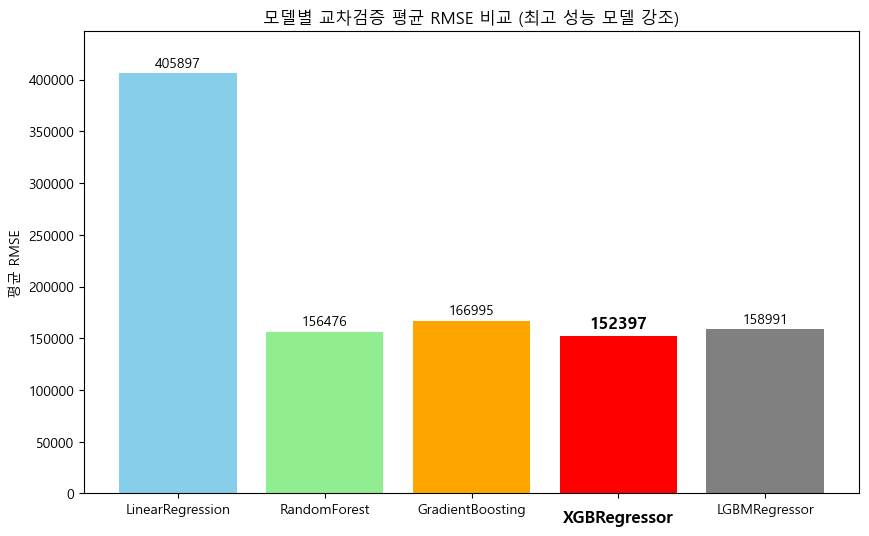

In [131]:
model_names = ['LinearRegression', 'RandomForest', 'GradientBoosting', 'XGBRegressor', 'LGBMRegressor']
rmse_means = [405897.27, 156475.64, 166995.41, 152397.43, 158990.81]

# RMSE가 가장 낮은 모델 인덱스
min_rmse_idx = np.argmin(rmse_means)

# 색상 지정 (기본 색상)
colors = ['skyblue', 'lightgreen', 'orange', 'purple', 'gray']
colors[min_rmse_idx] = 'red'  # 최저 RMSE 모델은 빨간색

plt.figure(figsize=(10,6))
bars = plt.bar(model_names, rmse_means, color=colors)
plt.ylabel("평균 RMSE")
plt.title("모델별 교차검증 평균 RMSE 비교 (최고 성능 모델 강조)")

# 막대 위 숫자 표시 및 강조
for i, bar in enumerate(bars):
    yval = bar.get_height()
    xval = bar.get_x() + bar.get_width() / 2
    
    if i == min_rmse_idx:
        plt.text(xval, yval + 3000, f'{yval:.0f}', ha='center', va='bottom',
                 fontsize=12, fontweight='bold', color='black')
        plt.text(xval, -15000, model_names[i], ha='center', va='top',
                 fontsize=12, fontweight='bold', color='black')
    else:
        plt.text(xval, yval + 3000, f'{yval:.0f}', ha='center', va='bottom',
                 fontsize=10, color='black')

# x축 기본 라벨 제거 (최고 성능 모델만 직접 라벨로 표시했기 때문)
plt.xticks([i for i in range(len(model_names))], ['' if i == min_rmse_idx else name for i, name in enumerate(model_names)])

plt.ylim(0, max(rmse_means)*1.1)
plt.show()


| 모델               | 평균 MSE               | 평균 RMSE      | 평균 R²   |
| ---------------- | -------------------- | ------------ | ------- |
| LinearRegression | 287,195,219,896.5624 | 405,897.2742 | -0.6645 |
| RandomForest     | 26,450,630,522.1763  | 156,475.6388 | 0.8634  |
| GradientBoosting | 30,124,808,727.4980  | 166,995.4057 | 0.8454  |
| **XGBRegressor**     | 25,220,201,573.8556  | **152,397.4340** | **0.8699**  |
| LGBMRegressor    | 26,825,813,512.8869  | 158,990.8133 | 0.8614  |


채택한 모델:  **XGBRegressor**

다양한 모델을 비교한 결과, **XGBRegressor**가 가장 낮은 **RMSE(152,397.43)** 와 가장 높은 **R²(0.8699)** 점수를 기록하여 예측 성능이 우수하다고 판단되었으며, 복잡한 비선형 관계를 효과적으로 학습할 수 있는 부스팅 기반 모델이라는 점에서 최종적으로 채택하였다.

In [137]:
# 하이퍼파라미터 탐색 범위 설정
param_grid = param_grid = {
    'n_estimators': [300],          # 1개로 축소
    'learning_rate': [0.05, 0.1],  # 2개만
    'max_depth': [4],               # 1개로 축소
    'subsample': [0.8],             # 1개로 축소
    'colsample_bytree': [0.7, 0.9],# 2개만
    'gamma': [0, 1]                # 2개만
}



# XGB 모델
xgb = XGBRegressor(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # MSE 기준 최적화
    cv=5,
    n_jobs=-1,
    verbose=2
)

# 학습
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 및 CV RMSE 출력
best_params = grid_search.best_params_
best_rmse = np.sqrt(-grid_search.best_score_)

print("최적 하이퍼파라미터:", best_params)
print("최고 CV RMSE:", round(best_rmse, 4))

# 테스트셋 예측
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_test = np.maximum(y_pred_test, 0)  # 음수 방지

# 평가
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
rmsle_test = np.sqrt(mean_squared_log_error(y_test, y_pred_test))

print(f"Tuned XGBRegressor Test 결과: RMSE={rmse_test:.4f}, R2={r2_test:.4f}, RMSLE={rmsle_test:.4f}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits
최적 하이퍼파라미터: {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
최고 CV RMSE: 164748.9554
Tuned XGBRegressor Test 결과: RMSE=324611.8001, R2=0.6296, RMSLE=0.9720


In [138]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 1, 3, 5]
}

xgb = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,                # 무작위로 50개 조합 탐색
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
best_rmse = np.sqrt(-random_search.best_score_)

print("최적 하이퍼파라미터:", best_params)
print("최고 CV RMSE:", round(best_rmse, 4))

# 테스트셋 예측 및 평가
best_model = random_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_test = np.maximum(y_pred_test, 0)

from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
rmsle_test = np.sqrt(mean_squared_log_error(y_test, y_pred_test))

print(f"Tuned XGBRegressor Test 결과: RMSE={rmse_test:.4f}, R2={r2_test:.4f}, RMSLE={rmsle_test:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
최적 하이퍼파라미터: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 3, 'colsample_bytree': 0.9}
최고 CV RMSE: 157362.1039
Tuned XGBRegressor Test 결과: RMSE=305388.3795, R2=0.6721, RMSLE=0.3249


In [139]:
print(X_train.shape)
print(y_train.shape)

(7976, 202)
(7976,)


In [ ]:
param_dist = {
    'n_estimators': [400, 450],
    'learning_rate': [0.03],
    'max_depth': [7,8],
    'subsample': [0.9],
    'colsample_bytree': [0.9],
    'gamma': [3],
    'reg_alpha': [0, 0.1, 1, 5],      # L1 규제 (희소성 유도)
    'reg_lambda': [1, 5, 10, 20]      # L2 규제 (과적합 완화)
}


xgb = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,                # 50개 조합 무작위 탐색
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
best_rmse = np.sqrt(-random_search.best_score_)

print("최적 하이퍼파라미터:", best_params)
print("최고 CV RMSE:", round(best_rmse, 4))

best_model = random_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_test = np.maximum(y_pred_test, 0)

from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
rmsle_test = np.sqrt(mean_squared_log_error(y_test, y_pred_test))

print(f"Tuned XGBRegressor Test 결과: RMSE={rmse_test:.4f}, R2={r2_test:.4f}, RMSLE={rmsle_test:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
